# Match Left side and Right side of fin
在制作 preview slide 时，匹配并移动 Fin

根据 Fin 像素大小排序，选像素最高者

In [5]:
import cv2
import os
import glob
import shutil
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import image_grid
from wildlife_tools.data import FeatureDataset

In [2]:
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-1/"
features = FeatureDataset.from_file(root_dir + "/deepfeatures_MERGED")

In [3]:
features.metadata

,identity,path,crop_conf,x_min,x_max,y_min,y_max,orig_img,orig_img_h,orig_img_w,identify,clearness,select,FinID
0,6,FIN/0018_20240825JM02ZRA10892_FIN01.JPG,0.650631,785,958,1480,1593,0018_20240825JM02ZRA10892.JPG,2880,4320,6,0.196129,True,3
1,8,FIN/0019_20240825JM02ZRA10893_FIN01.JPG,0.751839,776,958,1453,1581,0019_20240825JM02ZRA10893.JPG,2880,4320,8,0.410990,True,3
2,12,FIN/0021_20240825JM02ZRA10895_FIN01.JPG,0.776361,2065,2251,1356,1504,0021_20240825JM02ZRA10895.JPG,2880,4320,12,0.116618,True,0
3,34,FIN/0035_20240825JM02ZRA10909_FIN00.JPG,0.815389,1677,1924,1604,1765,0035_20240825JM02ZRA10909.JPG,2880,4320,34,0.177605,True,2
4,38,FIN/0039_20240825JM02ZRA10913_FIN00.JPG,0.813887,2210,2433,1491,1638,0039_20240825JM02ZRA10913.JPG,2880,4320,38,0.467952,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3704,4529,FIN/3471_20240825JM02ZRA14347_FIN00.JPG,0.861220,1952,2374,1277,1519,3471_20240825JM02ZRA14347.JPG,2880,4320,4529,0.799429,True,10
3705,4530,FIN/3472_20240825JM02ZRA14348_FIN00.JPG,0.861207,2073,2501,1329,1573,3472_20240825JM02ZRA14348.JPG,2880,4320,4530,0.986161,True,10
3706,4531,FIN/3473_20240825JM02ZRA14349_FIN00.JPG,0.866551,2191,2620,1328,1570,3473_20240825JM02ZRA14349.JPG,2880,4320,4531,0.884511,True,10
3707,4532,FIN/3474_20240825JM02ZRA14350_FIN00.JPG,0.858289,2230,2658,1340,1581,3474_20240825JM02ZRA14350.JPG,2880,4320,4532,0.854104,True,10


In [41]:
# Scan the dophin id from folder structure DphID->FinID->FinImageID
features.metadata["DphID"] = 0
features.metadata["FinID2"] = 0
dolphin_list = glob.glob(os.path.join(root_dir + "/FIN", 'DphID*'))
dolphin_list.sort()
for dolphin in dolphin_list:
    dolphin_id = int(os.path.basename(dolphin)[5:]) # DphIDxxx
    fin_list  = glob.glob(os.path.join(dolphin, 'FinID*'))
    for fin in fin_list:
        fin_id = int(os.path.basename(fin)[5:]) # FinIDxxx
        fin_image_list = glob.glob(os.path.join(fin, '*.JPG'))
        for fin_image in fin_image_list:
            fin_image_name = "FIN/" + os.path.basename(fin_image)    
            features.metadata.loc[ features.metadata['path']==fin_image_name, "FinID2"] = fin_id
            features.metadata.loc[ features.metadata['path']==fin_image_name, "DphID"] = dolphin_id

In [49]:
features.metadata.to_csv(root_dir + "/FIN_METAINFO_SELECTED_MERGED_PAIRED.csv")
features.save(root_dir + "FIN_DEEPFEATURES_SELECTED_MERGED_PAIRED")

In [6]:
def creat_empty_folder(folder):
    folder_path = Path(folder)
    if folder_path.exists():
        shutil.rmtree(folder_path)
        print(f"Deleted: {folder_path}")
    os.mkdir(folder)

In [54]:
features.metadata["DphID"].unique()

array([ 3,  0,  2,  5,  1, 14,  8,  7,  4,  6, 15, 11, 10, 13,  9, 12])

In [55]:
# move original image to subfolder
DphID_list = features.metadata["DphID"].unique()

for DphID in DphID_list:
    paths = features.metadata.query("DphID==%d"%DphID)['orig_img']
    if DphID != 0:
        dest_dir = root_dir + "/DphID%03d/"%DphID
        creat_empty_folder(dest_dir)
    else:
        dest_dir = root_dir + "/Quality below 60/"
    for dolphin in paths:
        src = root_dir + "/" + dolphin
        dest = dest_dir + dolphin
        if not os.path.exists(dest):
            os.symlink(src, dest)

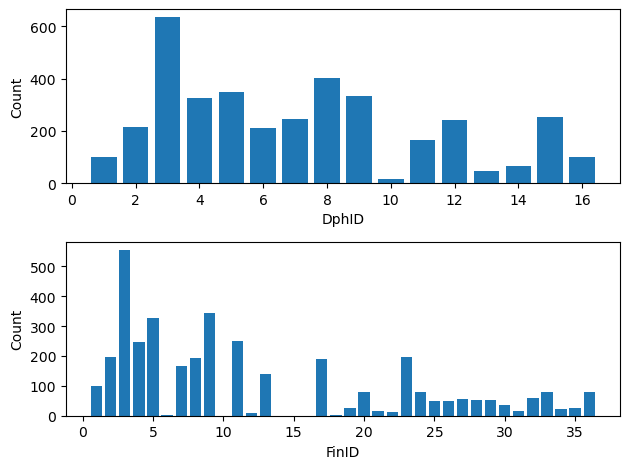

In [110]:
# Plot Statistics

DphID_hist  = features.metadata.DphID.value_counts()
plt.subplot(2, 1, 1)
plt.bar(DphID_hist.index.values+1, DphID_hist.values)
plt.xlabel("DphID")
plt.ylabel("Count")
plt.subplot(2, 1, 2)
FinID_hist = features.metadata.FinID2.value_counts()
plt.bar(FinID_hist.index.values + 1, FinID_hist.values)
plt.xlabel("FinID")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(root_dir + "FIN_PAIR_STASTISTICS.png")

## Find NN

In [111]:
features.metadata["automatic_group"] = ""

In [113]:
dolphin_count_in_img = features.metadata.orig_img[features.metadata.DphID !=0 ].value_counts() 
# exclude unclassied dolphin
NN_group_dict = dict()
creat_empty_folder(root_dir + "/NN")
for i in range(len(dolphin_count_in_img)):
    img_name = dolphin_count_in_img.index[i]
    dolphin_count = dolphin_count_in_img[img_name]
    if dolphin_count > 1:
        dolphins_in_same_img = features.metadata.query("orig_img=='%s'"%(img_name))
        NNGroupName = ""
        dolphin_id_list = dolphins_in_same_img.DphID.sort_values().values
        for dolphin_id in dolphin_id_list:
            NNGroupName = NNGroupName + "_DphID%03d"%dolphin_id
        src = root_dir + "/" + img_name
        dest_dir = root_dir + "/NN/" + NNGroupName[1:] 
        dest = dest_dir + "/" + img_name
        if not Path(dest_dir).exists():
            os.mkdir(dest_dir)
        if not os.path.exists(dest):
            os.symlink(src, dest)

Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/NN


In [223]:
dolphin_count_in_img = features.metadata.orig_img[features.metadata.DolphinID !=0 ].value_counts() 
# exclude unclassied dolphin
NN_group_dict = dict()
for i in range(len(dolphin_count_in_img)):
    img_name = dolphin_count_in_img.index[i]
    dolphin_count = dolphin_count_in_img[img_name]
    if dolphin_count > 1:
        dolphins_in_same_img = features.metadata.query("orig_img=='%s'"%(img_name))
        NNGroupName = ""
        dolphin_id_list = dolphins_in_same_img.DolphinID.sort_values().values
        for dolphin_id in dolphin_id_list:
            NNGroupName = NNGroupName + "_DphID%03d"%dolphin_id
        NNGroupName = NNGroupName[1:]
        if not NNGroupName in NN_group_dict.keys():
            NN_group_dict[NNGroupName] = []
        NN_group_dict[NNGroupName].append(img_name)

In [256]:
group_idx = 1
for key in NN_group_dict.keys():
    group_name = "NN%02d"%group_idx
    for img in NN_group_dict[key]:
        features.metadata.loc[ features.metadata['orig_img']==img, "automatic_group"] = group_name
    group_idx = group_idx + 1

In [115]:
features.metadata.automatic_group.value_counts()

automatic_group
    3709
Name: count, dtype: int64

In [258]:
features.metadata.to_csv(root_dir + "FILTERED_metainfo_with_FinID_with_dolphinID_with_groupID.csv")

In [259]:
features.metadata["confirmed_group"] = ""

In [272]:
# find the dophin id from folder structure
MCP_dir = root_dir + "/MCP"
MCP_list = os.listdir(MCP_dir)
MCP_list.sort()
MCP_idx = 1
for MCP in MCP_list:
    img_list  = glob.glob(os.path.join(MCP_dir + "/" + MCP, '*.JPG'))
    MCP_name = "MCP%02d"%(MCP_idx)
    for  img in img_list:
        img_name = os.path.basename(img)
        features.metadata.loc[ features.metadata['orig_img']==img_name, "confirmed_group"] = MCP_name
    MCP_idx = MCP_idx + 1
features.metadata.to_csv(root_dir + "/FILTERED_metainfo_with_FinID_with_dolphinID_with_automatic_confirm_group.csv")
features.save(root_dir + "FILTERED_deepfeatures_with_label_with_dolphinID_with_automatic_confirm_group")

In [275]:
# find the dophin id from folder structure
NN_dir = root_dir + "/NN"
NN_list = os.listdir(NN_dir)
NN_list.sort()
NN_idx = 1
for NN in NN_list:
    img_list  = glob.glob(os.path.join(NN_dir + "/" + NN, '*.JPG'))
    NN_name = "NN%02d"%(NN_idx)
    for  img in img_list:
        img_name = os.path.basename(img)
        features.metadata.loc[ features.metadata['orig_img']==img_name, "confirmed_group"] = NN_name
    NN_idx = NN_idx + 1
features.metadata.to_csv(root_dir + "/FILTERED_metainfo_with_FinID_with_dolphinID_with_automatic_confirm_group.csv")
features.save(root_dir + "FILTERED_deepfeatures_with_label_with_dolphinID_with_automatic_confirm_group")

In [273]:
features.metadata.confirmed_group.value_counts()

confirmed_group
         1616
MCP03      32
MCP01      28
MCP04      22
MCP05      22
MCP02       6
Name: count, dtype: int64

In [283]:
features.metadata.orig_img.unique()

array(['1214_20240824JM01ZRA11214.JPG', '1215_20240824JM01ZRA11215.JPG',
       '1216_20240824JM01ZRA11216.JPG', ...,
       '0045_20240824JM01ZRA10045.JPG', '0046_20240824JM01ZRA10046.JPG',
       '0047_20240824JM01ZRA10047.JPG'], shape=(1633,), dtype=object)

In [291]:
# move low quality images
features.metadata.loc[features.metadata['DolphinID'] !=0, 'orig_img'].unique()

array(['1214_20240824JM01ZRA11214.JPG', '1215_20240824JM01ZRA11215.JPG',
       '1216_20240824JM01ZRA11216.JPG', ...,
       '0069_20240824JM01ZRA10069.JPG', '0071_20240824JM01ZRA10071.JPG',
       '0072_20240824JM01ZRA10072.JPG'], shape=(1477,), dtype=object)

In [288]:
unclassied_img  = [i for i in features.metadata.orig_img.unique() if i not in features.metadata.loc[features.metadata['DolphinID'] !=0, 'orig_img'].unique()]

In [293]:
for img in unclassied_img:
    src = root_dir + "/" + img
    dest_dir = root_dir + "/Quality below 60"
    dest = dest_dir + "/" + img
    if not Path(dest_dir).exists():
        os.mkdir(dest_dir)
    if not os.path.exists(dest):
        os.symlink(src, dest)

Convert softlink to regular file
```bash
for f in $(find MCP/ -type l);do cp --remove-destination $(readlink $f) $f;done;
```